## 45 Days ML Journey - Day03

### EDA

In [1]:
# import necessary libs.

import numpy as np
import pandas as pd

In our previous day, we performed data cleaning, here we're using the cleaned dataset.

### Basic EDA operations
1. shape of dataset.
2. datatypes.
3. memory usage
4. preview of data.

In [2]:
df = pd.read_csv("../titanic_clean.csv")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  891 non-null    int64  
 1   Survived    891 non-null    int64  
 2   Pclass      891 non-null    int64  
 3   Age         891 non-null    float64
 4   Fare        891 non-null    float64
 5   Sex_female  891 non-null    int64  
 6   Sex_male    891 non-null    int64  
 7   Embarked_C  891 non-null    int64  
 8   Embarked_Q  891 non-null    int64  
 9   Embarked_S  891 non-null    int64  
 10  FamilySize  891 non-null    int64  
dtypes: float64(2), int64(9)
memory usage: 76.7 KB


In [3]:
# shape of dataset.
print(df.shape)

print("Total no. of rows: ", df.shape[0])
print("Total no. of columns: ", df.shape[1])

(891, 11)
Total no. of rows:  891
Total no. of columns:  11


In [4]:
# for each column print the corresponding dtype
columns = df.columns
for col in columns:
    print(f"Column Name: {col}\t\tDtype: {(df[col].dtype)}")

Column Name: Unnamed: 0		Dtype: int64
Column Name: Survived		Dtype: int64
Column Name: Pclass		Dtype: int64
Column Name: Age		Dtype: float64
Column Name: Fare		Dtype: float64
Column Name: Sex_female		Dtype: int64
Column Name: Sex_male		Dtype: int64
Column Name: Embarked_C		Dtype: int64
Column Name: Embarked_Q		Dtype: int64
Column Name: Embarked_S		Dtype: int64
Column Name: FamilySize		Dtype: int64


In [5]:
# view the memory usage of column
for col in columns:
    print(f"Column name: {col}\t\tMemory Usage: {( df[col].memory_usage(deep=True) )} bytes")

Column name: Unnamed: 0		Memory Usage: 7260 bytes
Column name: Survived		Memory Usage: 7260 bytes
Column name: Pclass		Memory Usage: 7260 bytes
Column name: Age		Memory Usage: 7260 bytes
Column name: Fare		Memory Usage: 7260 bytes
Column name: Sex_female		Memory Usage: 7260 bytes
Column name: Sex_male		Memory Usage: 7260 bytes
Column name: Embarked_C		Memory Usage: 7260 bytes
Column name: Embarked_Q		Memory Usage: 7260 bytes
Column name: Embarked_S		Memory Usage: 7260 bytes
Column name: FamilySize		Memory Usage: 7260 bytes


In [6]:
# preview of data, top 5 rows
df.head(5)

,Unnamed: 0,Survived,Pclass,Age,Fare,Sex_female,Sex_male,Embarked_C,Embarked_Q,Embarked_S,FamilySize
0,0,0,3,22.0,7.2500,0,1,0,0,1,2
1,1,1,1,38.0,71.2833,1,0,1,0,0,2
2,2,1,3,26.0,7.9250,1,0,0,0,1,1
3,3,1,1,35.0,53.1000,1,0,0,0,1,2
4,4,0,3,35.0,8.0500,0,1,0,0,1,1


In [7]:
# last 5 rows
df.tail(5)

,Unnamed: 0,Survived,Pclass,Age,Fare,Sex_female,Sex_male,Embarked_C,Embarked_Q,Embarked_S,FamilySize
886,886,0,2,27.000000,13.00,0,1,0,0,1,1
887,887,1,1,19.000000,30.00,1,0,0,0,1,1
888,888,0,3,29.699118,23.45,1,0,0,0,1,4
889,889,1,1,26.000000,30.00,0,1,1,0,0,1
890,890,0,3,32.000000,7.75,0,1,0,1,0,1


In [8]:
# 5 random rows
df.sample(5)

,Unnamed: 0,Survived,Pclass,Age,Fare,Sex_female,Sex_male,Embarked_C,Embarked_Q,Embarked_S,FamilySize
319,319,1,1,40.00,134.5000,1,0,1,0,0,3
448,448,1,3,5.00,19.2583,1,0,1,0,0,4
562,562,0,2,28.00,13.5000,0,1,0,0,1,1
92,92,0,1,46.00,61.1750,0,1,0,0,1,2
831,831,1,2,0.83,18.7500,0,1,0,0,1,3


### Other EDA task includes

1. Survival dist.
2. Survival percentage
3. Age, Passenger class, Fare dist.
4. Gender, Passenger class, Embarked port

In [9]:
# for visualization part lib. like Seaborn and matplotlib are used.

import matplotlib.pyplot as plt
import seaborn as sns

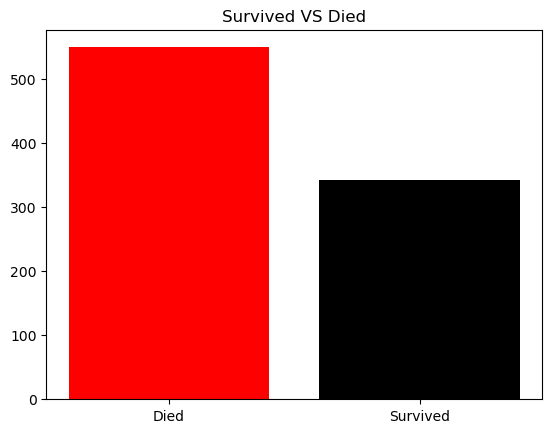

In [11]:
survival_count = df.Survived.value_counts().sort_index()
names = ["Died", "Survived"]
vals = [ survival_count.iloc[0], survival_count.iloc[1] ]
color_bars = ["red", "black"]

plt.bar(names, vals, label=bar_labels, color=color_bars)
plt.title("Survived VS Died")
plt.show()

percentage of peoples survived and died

In [14]:
print("Percentage of people died: ", ( vals[0] / sum(vals) )*100 )
print("Percentage of people survied: ", ( vals[1] / sum(vals) )*100 )

Percentage of people died:  61.61616161616161
Percentage of people survied:  38.38383838383838


For plotting the `Age` and `Fare` dist. we first have to standardize these values.
<br/>
For this we're using the `StandardScaler` of sklearn class

In [41]:
from sklearn.preprocessing import StandardScaler

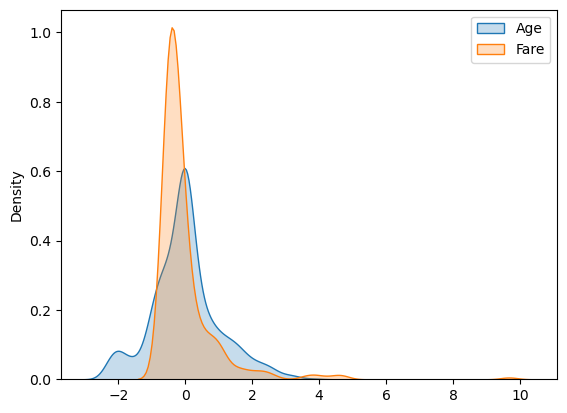

In [44]:
scaler = StandardScaler()

age_scaled = scaler.fit_transform(df.Age.values.reshape(-1,1)).flatten()
fare_scaled = scaler.fit_transform(df.Fare.values.reshape(-1,1)).flatten()

sns.kdeplot(x=age_scaled, label="Age", fill=True)
sns.kdeplot(x=fare_scaled, label="Fare", fill=True)

plt.legend()
plt.show()

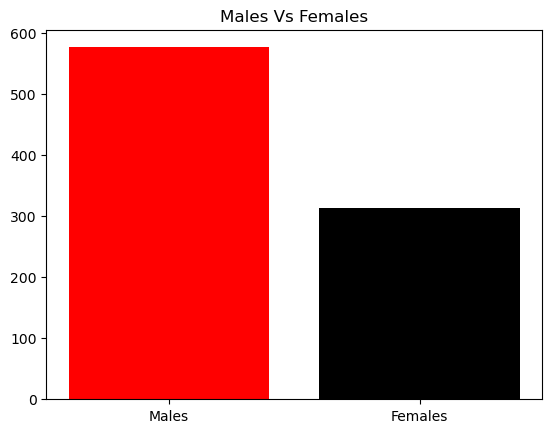

In [62]:
males = df.Sex_male.sum()
females = df.Sex_female.sum()
color_bars = ["red", "black"]

plt.bar(["Males", "Females"], [males, females], color=color_bars)
plt.title("Males Vs Females")
plt.show()

### Plot Graphs for
1. (Gender, Age, Pclass, Fare, Embarked) vs Survival
2. Correlation heatmaps
3. Age group segmentation (Create bins for Child, Teen, Adult, Senior)
4. Fare Binning (Create fare ranges and analyze survival)
5. Compare passenger count per class
6. Outlier detection using IQR and Boxplots.

<Axes: xlabel='Sex_male', ylabel='count'>

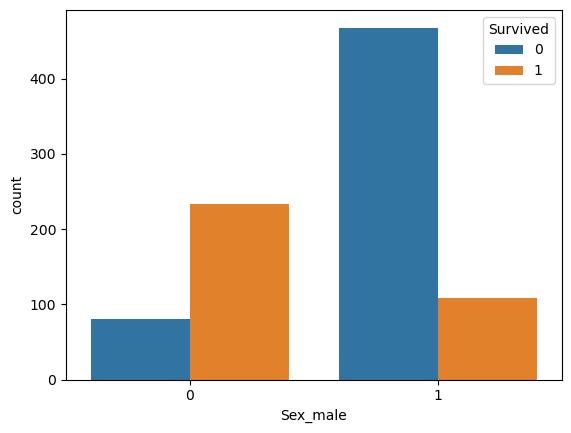

In [93]:
# gender vs survival graph
sns.countplot(data=df, x="Sex_male", hue="Survived")

<Axes: xlabel='Age', ylabel='Density'>

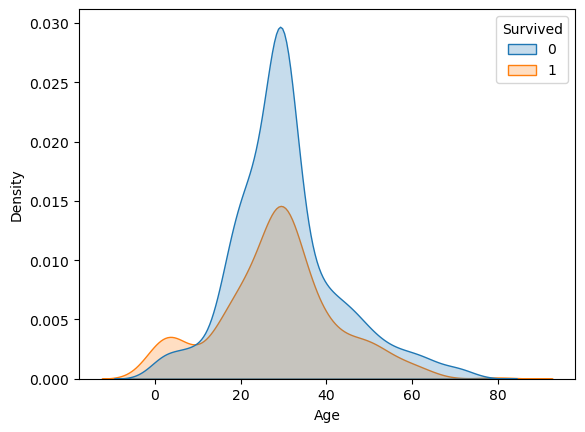

In [94]:
sns.kdeplot(data=df, x="Age", hue="Survived", fill=True)

<Axes: xlabel='Pclass', ylabel='count'>

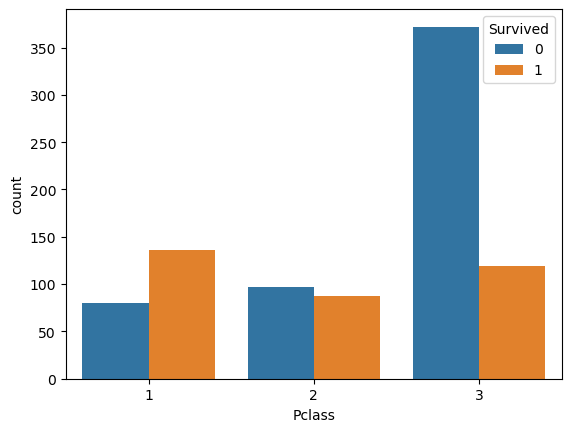

In [95]:
sns.countplot(data=df, x="Pclass", hue="Survived")

<Axes: xlabel='Fare', ylabel='Density'>

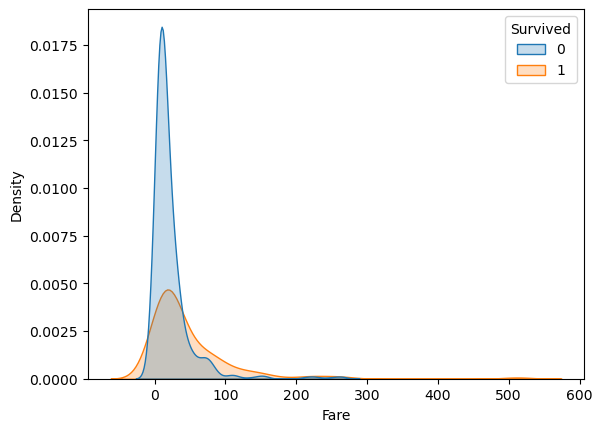

In [96]:
sns.kdeplot(data=df, x="Fare", hue="Survived", fill=True)

<Axes: xlabel='Embarked', ylabel='count'>

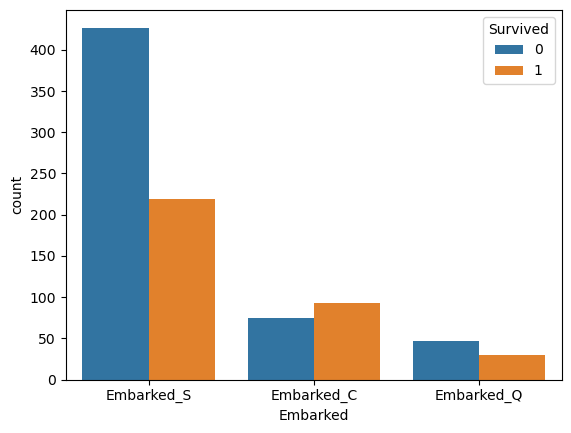

In [101]:
df["Embarked"] = df[["Embarked_Q","Embarked_S","Embarked_C"]].idxmax(axis=1)
sns.countplot(data=df, x="Embarked", hue="Survived")

<Axes: >

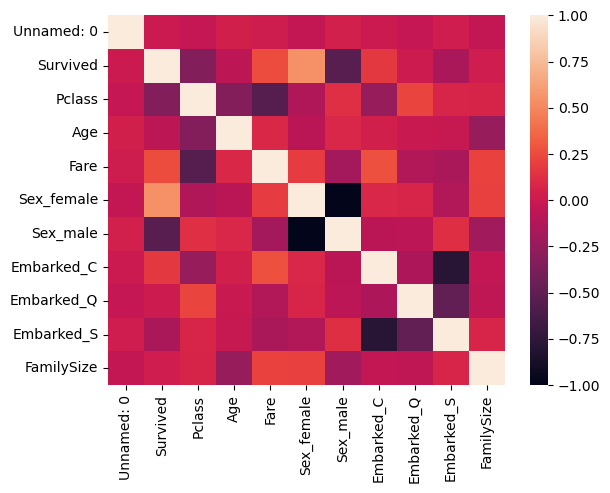

In [64]:
# correlation heatmap
sns.heatmap(df.corr())

<Axes: xlabel='AgeGroup', ylabel='count'>

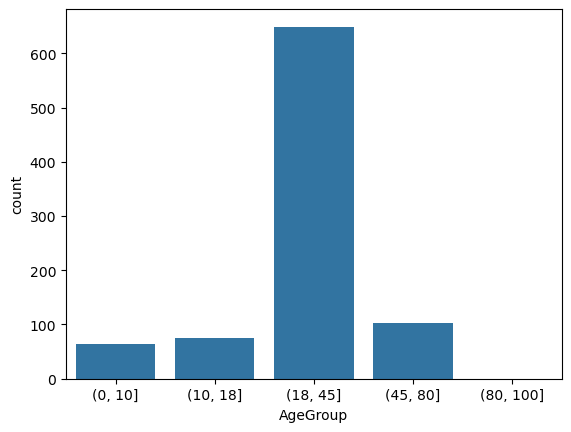

In [67]:
# age group segmentation
df["AgeGroup"] = pd.cut(df["Age"], bins=[0,10,18,45,80,100])
sns.countplot(data=df, x="AgeGroup")

<Axes: xlabel='FareGroup', ylabel='count'>

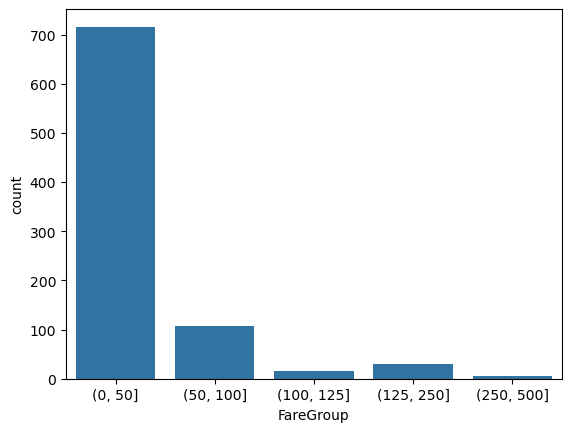

In [83]:
df["FareGroup"] = pd.cut( df["Fare"], bins=[0, 50, 100, 125, 250, 500] )
sns.countplot(data=df, x="FareGroup")

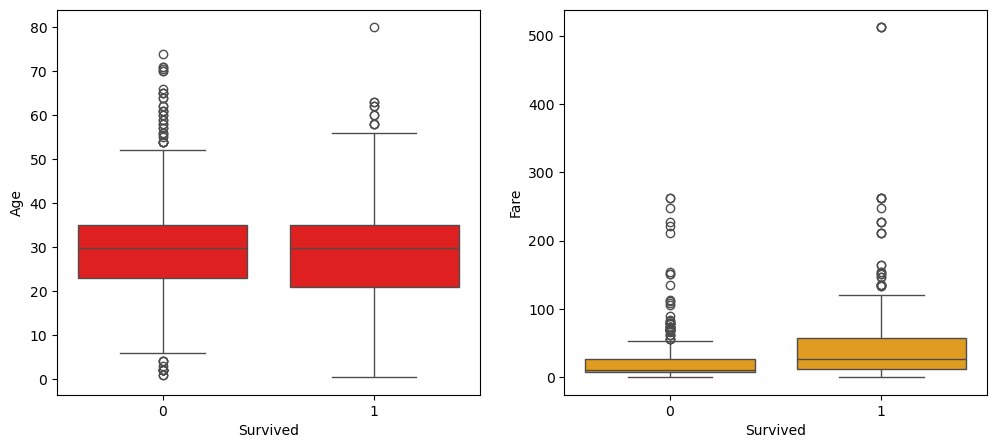

In [77]:
# outlier detection code
plt.figure(figsize=(12,5))
plt.subplot(1, 2, 1)
sns.boxplot(data=df, x="Survived", y="Age", color="red")
plt.subplot(1, 2, 2)
sns.boxplot(data=df, x="Survived", y="Fare", color="orange")
plt.show()

<Axes: xlabel='Pclass'>

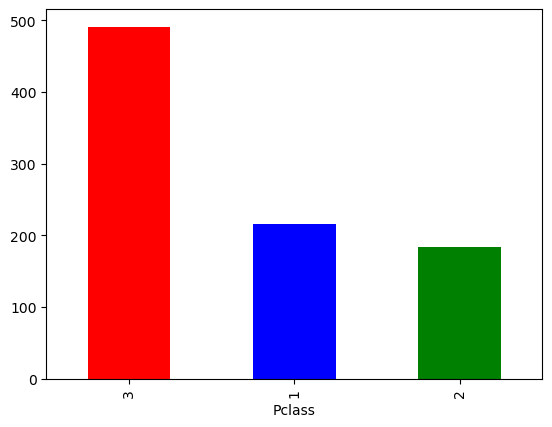

In [81]:
# per class passenger count
df.Pclass.value_counts().plot(kind='bar',
                             color=["red", "blue", "green"])